In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import cesium.featurize as ft
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [2]:
stock_df = yf.download( \
    ['AMZN'], \
    start='2015-01-01', \
    end='2020-12-31', \
    progress=False)
stock_df = stock_df.dropna()
ts = stock_df['Adj Close']

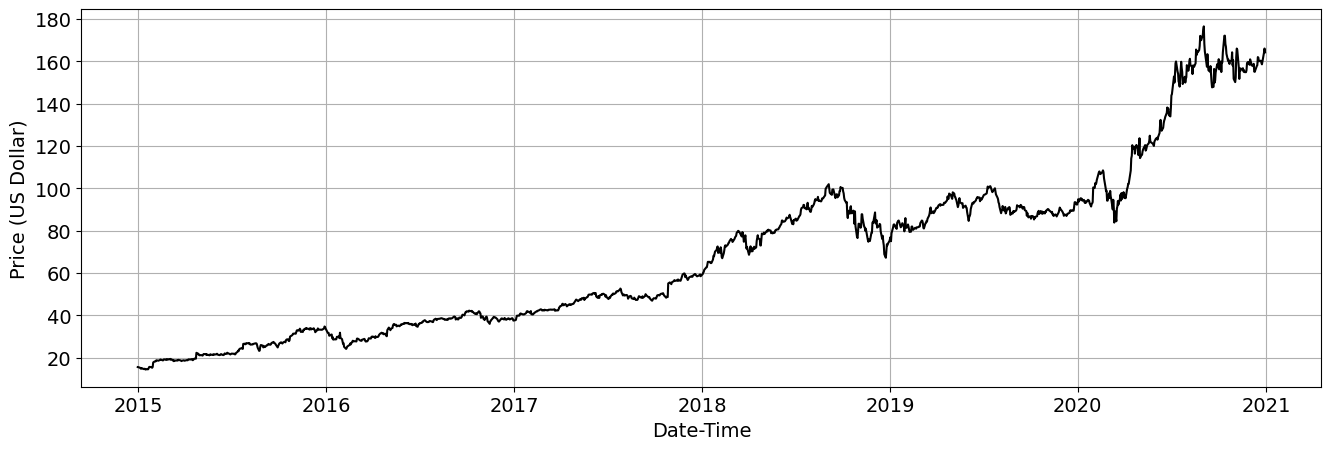

In [3]:
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(16, 5), dpi=100)
plt.plot(stock_df['Adj Close'], color='k')
plt.gca().set(xlabel='Date-Time', \
    ylabel='Price (US Dollar)')
plt.grid()
plt.show()

In [4]:
ws = 5

# %% label data points with binary classes
classes = np.where(ts > ts.shift(), \
    'bull', 'bear')[0:len(ts)-ws]

# %% extract values per sliding window
data = np.lib.stride_tricks.\
    sliding_window_view(ts, 5, writeable=True)\
    [0:len(ts)-ws]

# %% convert array of lists to list of arrays
data = list(map(np.asarray, data))

In [5]:
times = np.tile(np.arange(0, ws), \
    (len(data), 1))

# %% define features to be generated
features_to_extract = [ \
    "amplitude", "percent_beyond_1_std", \
    "percent_close_to_median", "skew", \
    "max_slope","mean", "std", "minimum", \
    "median", "maximum", "median", \
    "weighted_average", "median_absolute_deviation"]

In [6]:
fset_cesium = ft.featurize_time_series( \
    times = times, \
    values = data, \
    features_to_use = features_to_extract, \
    scheduler = None)


In [7]:
X_train, X_test, y_train, y_test = train_test_split( \
    fset_cesium.values, classes, random_state=21)

# %% build and train the model
rf_clf = RandomForestClassifier( \
    n_estimators=100, \
    max_depth=None, random_state=21)
rf_clf.fit(X_train, y_train)

# %% model evaluation
acc = rf_clf.score(X_test, y_test)
print('Mean Accuracy:', round(acc, 4))


Mean Accuracy: 0.4987


In [9]:
from sklearn.neural_network import MLPClassifier, MLPRegressor

# %% split the data
X_train, X_test, y_train, y_test = train_test_split( \
    data, ts[ws:], random_state=21)

# %% build and train the model
rgf = MLPRegressor(random_state=21, max_iter=500).\
    fit(X_train, y_train)

# %% model evaluation
acc = rgf.score(X_test, y_test)
print('R²:', round(acc, 4))

# console output:
# R²: 0.998

## MLP classification

# %% split into training and testing data sets
X_train, X_test, y_train, y_test = train_test_split( \
    fset_cesium.values, classes, random_state=21)

# %% build and train the model
clf = MLPClassifier(random_state=21, \
    max_iter=300, activation='tanh', \
    verbose=True).fit(X_train, y_train)

# %% model evaluation
acc = clf.score(X_test, y_test)
print('Mean Accuracy:', round(acc, 4))

R²: 0.998
Iteration 1, loss = 0.69764106
Iteration 2, loss = 0.69368685
Iteration 3, loss = 0.68299236
Iteration 4, loss = 0.68499954
Iteration 5, loss = 0.68286938
Iteration 6, loss = 0.68413873
Iteration 7, loss = 0.68318124
Iteration 8, loss = 0.68259175
Iteration 9, loss = 0.68246307
Iteration 10, loss = 0.68253426
Iteration 11, loss = 0.68182433
Iteration 12, loss = 0.68279609
Iteration 13, loss = 0.68185766
Iteration 14, loss = 0.68191943
Iteration 15, loss = 0.68066957
Iteration 16, loss = 0.67997766
Iteration 17, loss = 0.67991940
Iteration 18, loss = 0.68175913
Iteration 19, loss = 0.68017581
Iteration 20, loss = 0.68351811
Iteration 21, loss = 0.68069026
Iteration 22, loss = 0.68012286
Iteration 23, loss = 0.67920145
Iteration 24, loss = 0.68007475
Iteration 25, loss = 0.67990917
Iteration 26, loss = 0.68145447
Iteration 27, loss = 0.67868539
Iteration 28, loss = 0.67971466
Iteration 29, loss = 0.67877681
Iteration 30, loss = 0.67855973
Iteration 31, loss = 0.68120818
Iterati